In [1]:
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from pathlib import Path
import random
import numpy as np
import torch
import pandas as pd

from models_transformer import SingleOutTransformerNet
from shap_helpers import (compute_shap_3out, 
                          _ensure_2d_shap, 
                          mean_abs_shap, 
                          topk_table, 
                          global_table,
                          save_fig, 
                          cosine_spearman)

In [2]:
OUTDIR = Path("./Results")
SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
print("Device:", DEVICE)

Device: cpu


In [3]:
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

TOPK = 10  # MOD: Top 10 as requested
N_BG = 256

SHAP_DIR = OUTDIR / "shap_values"
FIG_DIR = SHAP_DIR / f"figs/sedd_{SEED}"
TAB_DIR = SHAP_DIR / f"tables/seed_{SEED}"
SHAP_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
test_data = np.load("data_processed/test_data_scaled.npz")
X_test = test_data["x"]

In [5]:
rng = np.random.default_rng(SEED)
n_test = X_test.shape[0]
idx_bg = rng.choice(n_test, size=min(N_BG, n_test), replace=False)
X_bg = X_test[idx_bg].astype(np.float32)
X_ex = X_test.astype(np.float32)  # explain all test

In [6]:
import pickle

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [7]:
bg_t = torch.from_numpy(X_bg).to(DEVICE)
ex_t = torch.from_numpy(X_ex).to(DEVICE)

In [8]:
# -----------------------------
# SHAP for TR single-output 
# -----------------------------
print("\n[SHAP] Computing for TR single-output models...")

class SinglePredictWrapper(torch.nn.Module):
    def __init__(self, model_single):
        super().__init__()
        self.model = model_single
    def forward(self, x):
        return self.model(x)

IN_DIM = X_test.shape[1]

EMB_DIM = 64
NHEAD = 4
NUM_LAYERS = 11
FF_DIM = 128
DROPOUT = 0.1

model = SingleOutTransformerNet(IN_DIM, emb_dim=EMB_DIM, nhead=NHEAD, 
                                num_layers=NUM_LAYERS, ff_dim=FF_DIM, 
                                dropout=DROPOUT).to(DEVICE)

sd = torch.load(f"trained_models/seed_{SEED}/{NUM_LAYERS}layers/TR_model_{NUM_LAYERS}layers.pt")
model.load_state_dict(sd)
model.eval()


[SHAP] Computing for TR single-output models...


SingleOutTransformerNet(
  (trunk): TransformerTrunkWithAttn(
    (tokenizer): FeatureTokenizer()
    (layers): ModuleList(
      (0-10): 11 x TransformerEncoderLayerWithAttn(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (dropout_attn): Dropout(p=0.1, inplace=False)
        (dropout_ff): Dropout(p=0.1, inplace=False)
        (dropout_act): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [9]:
wrapped = SinglePredictWrapper(model).to(DEVICE)
expl = shap.GradientExplainer(wrapped, bg_t)
sv = expl.shap_values(ex_t)
method_s = "GradientExplainer"

if isinstance(sv, list):
    sv = sv[0]
sv2 = _ensure_2d_shap(sv, tag="age")

ma = mean_abs_shap(sv2, tag="age")

# df_top = topk_table(ma, feature_names, TOPK, tag="age", tabdir=TAB_DIR)
# _ = global_table(ma, feature_names, tag="age", tabdir=TAB_DIR)

TypeError: topk_table() got an unexpected keyword argument 'tag'

In [10]:
df_top = topk_table(ma, feature_names, TOPK, tabdir=TAB_DIR)
_ = global_table(ma, feature_names, tabdir=TAB_DIR)

/tmp/ipykernel_296437/772597026.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv2[:, top_idx],


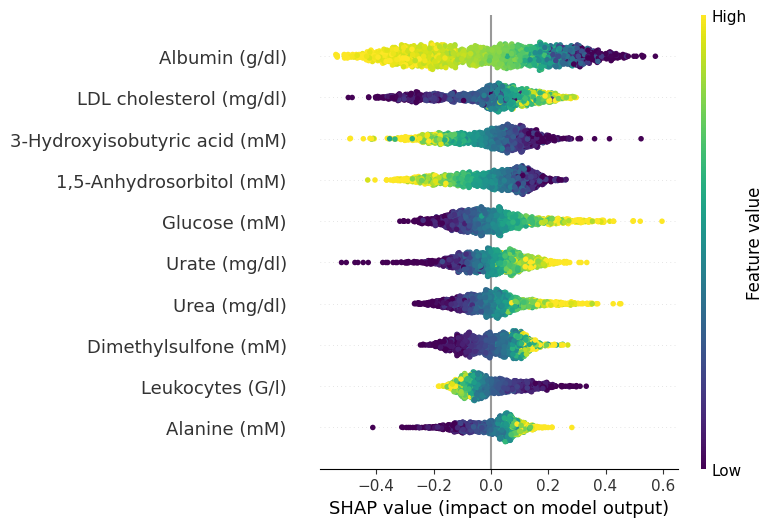

In [11]:
top_feats = df_top["feature"].tolist()
top_idx = [feature_names.index(f) for f in top_feats]

shap.summary_plot(sv2[:, top_idx], 
                  features=X_ex[:, top_idx], 
                  feature_names=top_feats, 
                  cmap="viridis", 
                  show=False)
# plt.gca().set_title(f"Transformer model age", loc="center",pad=15)
# save_fig(FIG_DIR / f"beeswarm_top{TOPK}_{NUM_LAYERS}layers")

np.savez_compressed(
    SHAP_DIR / f"shap_values_{NUM_LAYERS}layers_seed{SEED}.npz",
    X_ex=X_ex, X_bg=X_bg,
    shap_vals=sv2,
    feature_names=np.array(feature_names, dtype=object),
    method=np.array([method_s], dtype=object),
)